# Use case definitions — structure & comparison against the labelled exports

**ELI5:** each `*.usecase.json` in `data/raw/` is the **search brief** an analyst wrote
in `academic_research_agent` before any papers were found — problem statement,
objective, must/nice/exclude terms, TRL constraints, decision criteria. It's the
*intent* behind a use case; the matching `*.jsonl` export (see
`explore_use_cases.ipynb`) is the *result* — the papers that search actually
produced, labelled.

This notebook asks two questions:

1. **Structure** — do all 6 `usecase.json` files share the same schema? Which
   optional fields actually get filled in, and which are consistently left blank?
2. **Matching elements** — do the two file types agree on which use case is which
   (`usecase.json`'s `name` vs. the export's `_meta.use_case`), and how does each
   use case's *definition* (term counts, TRL window) line up against its *corpus*
   (paper count, label balance)?

Descriptive only, same as the other notebook — no cleaning or modelling here.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("../../data/raw")

SEQUENTIAL = "#2a78d6"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

## Load every usecase.json, and the matching JSONL export's papers + meta

Matching is by **`name`** (the field meant to identify a use case), not by filename —
`carbon_capture.usecase.json` happens to line up with `carbon_capture.jsonl` today,
but relying on filename slugs would break the moment one side's naming convention
drifts. That isn't hypothetical: these exports originally arrived under three
different conventions (`-all`, `-labelledFULLRUN`, and neither) and were later
renamed wholesale to the `<use_case_key>` pairs seen here. Matching on `name` is why
that rename cost nothing.


In [2]:
def load_usecase_def(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def load_jsonl_export(path: Path) -> tuple[dict, pd.DataFrame]:
    """Same loader as explore_use_cases.ipynb — split a JSONL export into its
    (meta, records) parts, identifying the meta line by content, not position."""
    meta = {}
    rows = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            d = json.loads(line)
            if set(d.keys()) == {"_meta"}:
                meta = d["_meta"]
            else:
                rows.append(d)
    return meta, pd.DataFrame(rows)


usecase_files = sorted(DATA_DIR.glob("*.usecase.json"))
jsonl_files = sorted(DATA_DIR.glob("*.jsonl"))

usecase_defs = {}
for f in usecase_files:
    d = load_usecase_def(f)
    usecase_defs[d["name"]] = {"file": f.name, "def": d}

jsonl_data = {}
for f in jsonl_files:
    meta, df = load_jsonl_export(f)
    jsonl_data[meta.get("use_case", f.stem)] = {"file": f.name, "meta": meta, "df": df}

print(f"Loaded {len(usecase_defs)} usecase.json files and {len(jsonl_data)} JSONL exports.")
unmatched_usecase = set(usecase_defs) - set(jsonl_data)
unmatched_jsonl = set(jsonl_data) - set(usecase_defs)
print(f"usecase.json names with no matching JSONL export: {unmatched_usecase or 'none'}")
print(f"JSONL use_case names with no matching usecase.json: {unmatched_jsonl or 'none'}")

Loaded 6 usecase.json files and 6 JSONL exports.
usecase.json names with no matching JSONL export: none
JSONL use_case names with no matching usecase.json: none


## 1. Structure of the usecase.json files

### 1a. Top-level schema

All 6 should be the same `schema_version`, with the same top-level keys — worth
confirming rather than assuming, the same way the other notebook checks the JSONL
exports' schema before trusting a `pd.concat` across them.

In [3]:
schema_versions = {name: d["def"].get("schema_version") for name, d in usecase_defs.items()}
top_level_keys = {name: frozenset(d["def"].keys()) for name, d in usecase_defs.items()}
same_schema_version = len(set(schema_versions.values())) == 1
same_top_level_keys = len(set(top_level_keys.values())) == 1

print(f"Same schema_version across all 6: {same_schema_version} ({set(schema_versions.values())})")
print(f"Same top-level keys across all 6: {same_top_level_keys}")
if same_top_level_keys:
    print(f"  keys: {sorted(next(iter(top_level_keys.values())))}")

Same schema_version across all 6: True ({'1.0'})
Same top-level keys across all 6: True
  keys: ['constraints', 'decision_criteria', 'domain', 'name', 'notes', 'objective', 'performance_criteria', 'problem_statement', 'schema_version', 'terms']


### 1b. Which nested fields are actually populated

The top-level schema matches, but that doesn't mean every field is *used* — an empty
string, empty list, or `null` is structurally valid but tells a different story than a
filled-in one. Same heatmap convention as `explore_use_cases.ipynb`'s schema-presence
chart (filled = populated, blank = empty/null), applied to the fields inside each
`usecase.json` that are optional in practice (`name`/`objective`/`problem_statement`/
`terms.must_include` are always populated in all 6, so they're left out — this heatmap
is about the fields that AREN'T guaranteed).

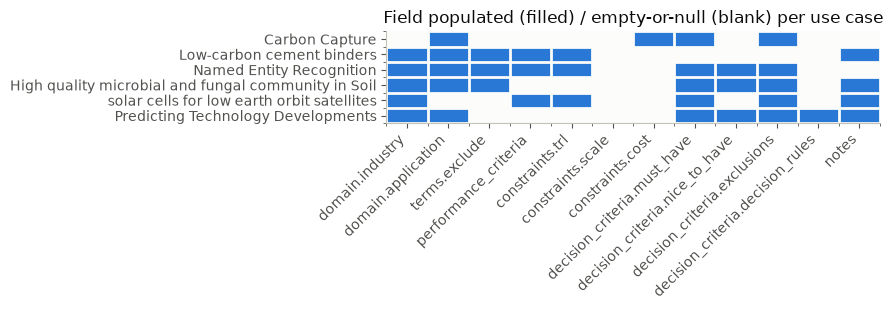

Fields that are empty/null in EVERY use case: ['constraints.scale']


In [4]:
def is_empty(v) -> bool:
    if v is None:
        return True
    if isinstance(v, str):
        return v.strip() == ""
    if isinstance(v, (list, dict)):
        return len(v) == 0
    return False


FIELD_GETTERS = {
    "domain.industry": lambda d: d["domain"]["industry"],
    "domain.application": lambda d: d["domain"]["application"],
    "terms.exclude": lambda d: d["terms"]["exclude"],
    "performance_criteria": lambda d: d["performance_criteria"],
    "constraints.trl": lambda d: d["constraints"]["trl"],
    "constraints.scale": lambda d: d["constraints"]["scale"],
    "constraints.cost": lambda d: d["constraints"]["cost"],
    "decision_criteria.must_have": lambda d: d["decision_criteria"]["must_have"],
    "decision_criteria.nice_to_have": lambda d: d["decision_criteria"]["nice_to_have"],
    "decision_criteria.exclusions": lambda d: d["decision_criteria"]["exclusions"],
    "decision_criteria.decision_rules": lambda d: d["decision_criteria"]["decision_rules"],
    "notes": lambda d: d["notes"],
}

use_case_names = list(usecase_defs.keys())
populated = pd.DataFrame(
    {name: [not is_empty(getter(usecase_defs[name]["def"])) for getter in FIELD_GETTERS.values()]
     for name in use_case_names},
    index=list(FIELD_GETTERS.keys()),
).T

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.imshow(populated.values.astype(int), cmap=plt.matplotlib.colors.ListedColormap(["#fcfcfb", SEQUENTIAL]),
          vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(FIELD_GETTERS)), FIELD_GETTERS.keys(), rotation=45, ha="right")
ax.set_yticks(range(len(populated.index)), populated.index)
ax.set_xticks(np.arange(-0.5, len(FIELD_GETTERS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(populated.index), 1), minor=True)
ax.grid(which="minor", color="#fcfcfb", linewidth=2)
ax.grid(which="major", visible=False)
ax.set_title("Field populated (filled) / empty-or-null (blank) per use case")
fig.tight_layout()
plt.show()

always_empty = [col for col in populated.columns if not populated[col].any()]
print("Fields that are empty/null in EVERY use case:", always_empty or "none")

**Finding:** `constraints.scale` is empty in all 6 — not yet a field analysts are
filling in, at least for these 6 use cases. `constraints.trl` and `performance_criteria`
are empty for exactly the same 3 use cases (carbon-capture, soil, predicting-technology)
— use cases without a stated TRL window also don't have stated performance targets,
which is consistent (a target without a maturity window to hit it in is hard to state).
`decision_criteria.decision_rules` is populated for only 1 of 6
(predicting-technology-developments) — most use cases rely on `must_have`/`exclusions`
alone, without a separate free-text decision rule.

## 2. Matching elements: definition vs. resulting corpus

One row per use case, joining the `usecase.json` definition against its matching JSONL
export — the actual "compare them" table.

In [5]:
def trl_range(constraints: dict) -> str:
    trl = constraints.get("trl")
    if not trl:
        return "not specified"
    return f'{trl.get("min", "?")}–{trl.get("max", "?")}'


comparison_rows = []
for name, uc in usecase_defs.items():
    d = uc["def"]
    jsonl = jsonl_data.get(name)
    label_counts = (
        jsonl["df"]["triage_label"].value_counts(dropna=False) if jsonl is not None else pd.Series(dtype=int)
    )
    comparison_rows.append({
        "use_case": name,
        "usecase_json_file": uc["file"],
        "jsonl_file": jsonl["file"] if jsonl else None,
        "name_match": jsonl is not None,
        "industry": d["domain"]["industry"] or "(not specified)",
        "trl_window": trl_range(d["constraints"]),
        "n_must_include": len(d["terms"]["must_include"]),
        "n_nice_to_have": len(d["terms"]["nice_to_have"]),
        "n_exclude_terms": len(d["terms"]["exclude"]),
        "n_performance_criteria": len(d["performance_criteria"]),
        "n_decision_exclusions": len(d["decision_criteria"]["exclusions"]),
        "n_papers": len(jsonl["df"]) if jsonl is not None else None,
        "n_positive": int(label_counts.get("positive", 0)),
        "n_negative": int(label_counts.get("negative", 0)),
        "n_pass": int(label_counts.get("pass", 0)),
        "n_untriaged": int(label_counts.get(np.nan, 0)) if jsonl is not None else None,
    })

comparison_table = pd.DataFrame(comparison_rows).sort_values("n_papers", ascending=False).reset_index(drop=True)
comparison_table

,use_case,usecase_json_file,jsonl_file,name_match,industry,trl_window,n_must_include,n_nice_to_have,n_exclude_terms,n_performance_criteria,n_decision_exclusions,n_papers,n_positive,n_negative,n_pass,n_untriaged
0,Low-carbon cement binders,cement_binders.usecase.json,cement_binders.jsonl,True,Cement & construction materials,1–4,4,2,2,2,0,690,170,92,105,323
1,High quality microbial and fungal community in...,soil_microbiome.usecase.json,soil_microbiome.jsonl,True,Agriculture,not specified,10,5,1,0,1,602,94,263,245,0
2,Named Entity Recognition,ner.usecase.json,ner.jsonl,True,Market intelligence / information extraction,6–9,4,6,4,3,2,541,223,89,74,155
3,solar cells for low earth orbit satellites,solar_leo.usecase.json,solar_leo.jsonl,True,solar cells for low earth orbit satellites,3–9,2,1,0,2,2,427,276,84,67,0
4,Carbon Capture,carbon_capture.usecase.json,carbon_capture.jsonl,True,(not specified),not specified,4,4,0,0,3,323,147,150,26,0
5,Predicting Technology Developments,tech_forecasting.usecase.json,tech_forecasting.jsonl,True,Heavy Industries,not specified,6,6,0,0,1,290,157,107,26,0


**Finding:** all 6 `usecase.json` names match a JSONL export's `_meta.use_case`
exactly (`name_match` is `True` throughout) — the join key is reliable, and it stayed
reliable across a later bulk rename of every file in `data/raw/`, precisely because it
never depended on the filenames. `solar cells for low earth orbit satellites` is the
one use case named in lowercase rather than Title Case in *both* files — consistent
with itself, just a style outlier versus the other 5. Term richness doesn't obviously
track corpus size (`tech_forecasting` has the smallest corpus but among the more
detailed term lists) — a use case's search brief being thorough doesn't guarantee a
large resulting pool.


## 3. Bonus: do the corpus's papers actually mention the definition's terms?

The comparison table above matches *structure/metadata*. This section checks *content*
— for each use case, what fraction of its papers mention at least one
`terms.must_include` phrase (should be high — that's what the search was built to
find), and what fraction mention an excluded term anyway (should be low — those may be
false positives that slipped through triage, or borderline calls). Plain
case-insensitive substring matching on `title + abstract` — no NLP, this is a coverage
sanity check, not a re-implementation of the agent's own relevance scoring.

In [6]:
def term_hit_rate(df: pd.DataFrame, terms: list[str]) -> float | None:
    if not terms:
        return None
    text = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.lower()
    pattern = "|".join(re.escape(t.lower()) for t in terms)
    return round(100 * text.str.contains(pattern, regex=True).mean(), 1)


coverage_rows = []
for name, uc in usecase_defs.items():
    jsonl = jsonl_data.get(name)
    if jsonl is None:
        continue
    d = uc["def"]
    coverage_rows.append({
        "use_case": name,
        "pct_papers_matching_must_include": term_hit_rate(jsonl["df"], d["terms"]["must_include"]),
        "pct_papers_matching_exclude_term": term_hit_rate(jsonl["df"], d["terms"]["exclude"]),
    })

pd.DataFrame(coverage_rows).sort_values("pct_papers_matching_must_include", ascending=False).reset_index(drop=True)

,use_case,pct_papers_matching_must_include,pct_papers_matching_exclude_term
0,Carbon Capture,89.8,NaN
1,Named Entity Recognition,79.1,4.1
2,solar cells for low earth orbit satellites,71.2,NaN
3,Predicting Technology Developments,60.7,NaN
4,Low-carbon cement binders,58.4,0.0
5,High quality microbial and fungal community in...,31.6,0.0


**Finding:** read `pct_papers_matching_exclude_term` as a flag to go look, not a
verdict — a paper can legitimately discuss an excluded concept in passing (e.g.
distinguishing itself from it) without being a false positive, and this is a substring
match, not a claim about what the paper is actually about. A use case with `n_exclude_terms
= 0` shows `None` here rather than `0` — there's nothing to check, which is a different
fact from "checked, found nothing."

**Not done here:** no decision about which flagged papers to re-triage or drop — that's
a judgement call for whoever owns each use case's labelling, using this as a starting
list rather than an automatic filter.